In [1]:
import WGS
import numpy as np
import scipy as sp
import torch
import torch.fft as fft
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from PIL import Image
import os
import time
import json
from Aberration import Zernike
from SLMGeneration import SLM_class
import json
import torch
from BlinkSLM import BlinkSLM
SLM = SLM_class()

SLM.image_init()

#blinkslm=BlinkSLM()

# slm_lib.Load_LUT_file(board_number,  b"C:\\Users\\Demeter\\Desktop\\slm.lut")
# 假设你的JSON文件和Notebook在同一目录下
# config_file_path = 'slm_config.json'

# # 读取并解析JSON文件
# with open(config_file_path, 'r') as file:
#     slm_config = json.load(file)
# Lattice_type=slm_config.get("Lattice_type")
# distance=slm_config.get("distance")
# spacing=slm_config.get("spacing")
# arraysize=slm_config.get("arraysize")
# translate=slm_config.get("translate")
# rotate=slm_config.get("rotate")
# angle=slm_config.get("angle")
# modify=slm_config.get("modify")
# # Plot=slm_config.get("Plot")
# # 打印配置以确认已正确加载
# print(slm_config)


ModuleNotFoundError: No module named 'numpy'

Focal pixelpitch: [4.16015625, 4.16015625]
The input gaussian light beam waist: 8450um
The init gaussian phase is random generated.


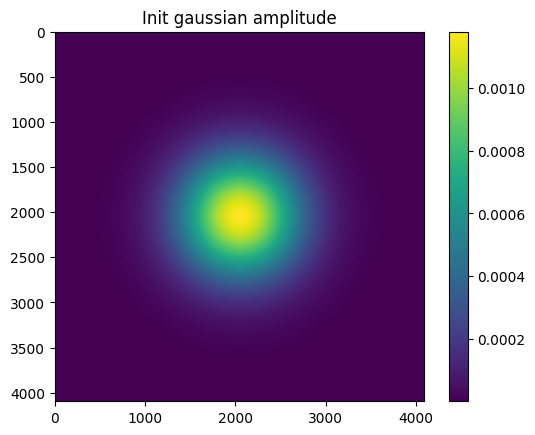

In [2]:
SLM.image_init(initGaussianPhase_user_defined = None, initGaussianPhase_save = False, Plot = True)
initSLMAmp=SLM.initGaussianAmp
# initSLMAmp=torch.from_numpy(initSLMAmp).float()  # 如果需要的话，可以改为 .double()
# initSLMPhase=np.random.rand(initSLMAmp.ImgResX, initSLMAmp.ImgResY)*2*np.pi-np.pi
plt.show()


focal pixelpitch: [4.16015625, 4.16015625]
array spacing: [500, 500]
spacing pixels: [120, 120]
arraysize: [5, 6]


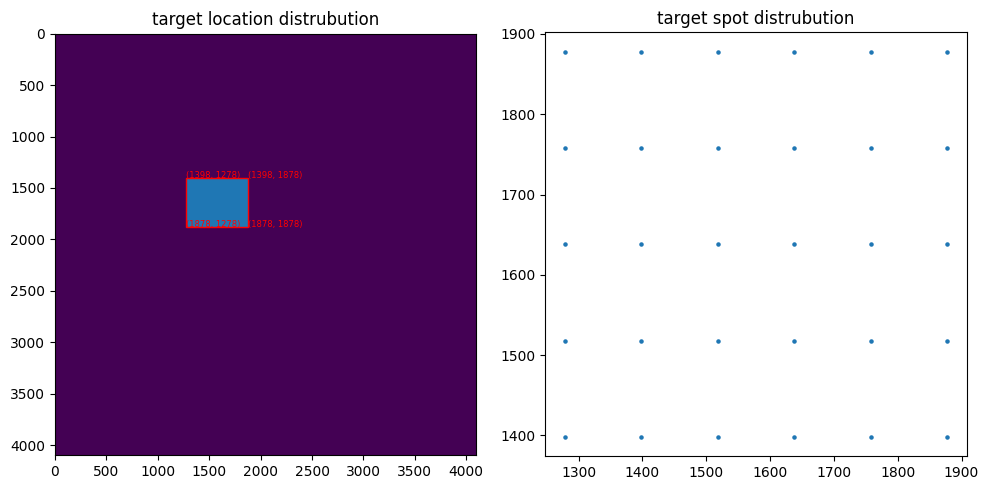

You have generated the target with 1000um distance relative to the center.


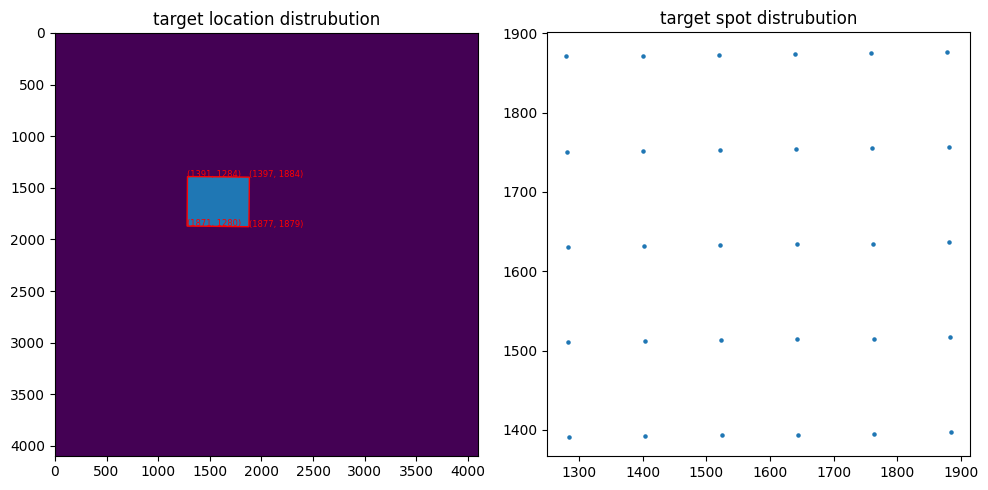

You have rotated the target by angle -0.5.


In [3]:
Lattice_type="Rec"

# targetAmp=SLM.target_generate(Lattice_type, distance, spacing, arraysize, translate, rotate, angle, modify, Plot = True)
targetAmp=SLM.target_generate(Lattice_type, spacing = [500,500], Plot = True)
# targetAmp=torch.from_numpy(targetAmp).float()

In [49]:
print(SLM.translate)

True


In [50]:
print(SLM.Loop)

25


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21684\1255350604.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  SLM_Phase=WGS.WGS_phase_generate(torch.tensor(initSLMAmp), torch.tensor(RandomPhase), torch.from_numpy(targetAmp), Loop=20, threshold=0.01, Plot=True)


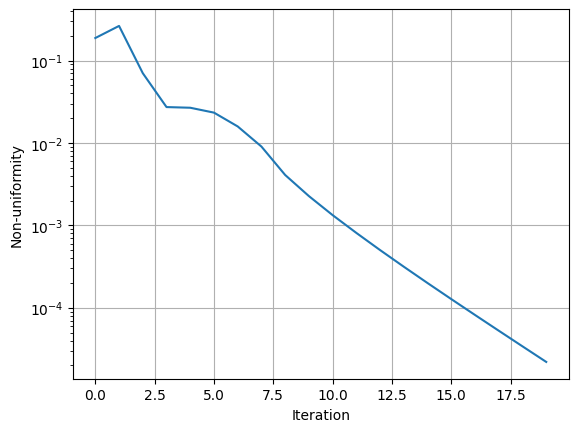

In [4]:
# 调用 WGS_phase_generate 函数
input_shape = (4096, 4096)  # 输入振幅分布的尺寸
# w0_input = 4096  # 高斯光斑的束腰半径
# initSLMPhase = torch.rand(input_shape, dtype=torch.float32) * 2 * np.pi - np.pi
# input_shape = (1024, 1024)  # 输入振幅分布的尺寸
RandomPhase = torch.rand(input_shape, dtype=torch.float32) * 2 * np.pi - np.pi

SLM_Phase=WGS.WGS_phase_generate(torch.tensor(initSLMAmp), torch.tensor(RandomPhase), torch.from_numpy(targetAmp), Loop=20, threshold=0.01, Plot=True)
SLM_screen=SLM.phase_to_screen(SLM_Phase.cpu().clone().numpy())
# fftAmp,fftPhase = SLM_class.phase_to_fftField(SLM_Phase)
# plt.figure(figsize=(20,20))
# plt.imshow(fftAmp[1000:3000,1000:3000])
# plt.show()
# 将 SLM 相位分布转换为复振幅分布
# SLM_Field = torch.multiply(initSLMAmp, torch.exp(1j * SLM_Phase))

# # 计算 FFT 并移至中心
# fftSLM = fft.fft2(SLM_Field)
# fftSLMShift = fft.fftshift(fftSLM)
# fftAmp = torch.abs(fftSLMShift)
# fftAmp_normalized = (fftAmp - fftAmp.min()) / (fftAmp.max() - fftAmp.min())

# 显示结果
# plt.figure(figsize=(8, 4))

# plt.subplot(1, 2, 1)
# plt.imshow(SLM_Phase.cpu().numpy(), cmap='jet')
# plt.title('Generated Phase Distribution')
# plt.colorbar(label='Phase (rad)')
# plt.axis('off')

# plt.subplot(1, 2, 2)
# plt.imshow(fftAmp_normalized.cpu().numpy(), cmap='gray')
# plt.title('FFT Magnitude (Normalized)')
# plt.colorbar(label='Magnitude')
# plt.axis('off')

# plt.tight_layout()
# plt.show()

In [8]:
np.save('SLM_img2.npy', SLM_screen)

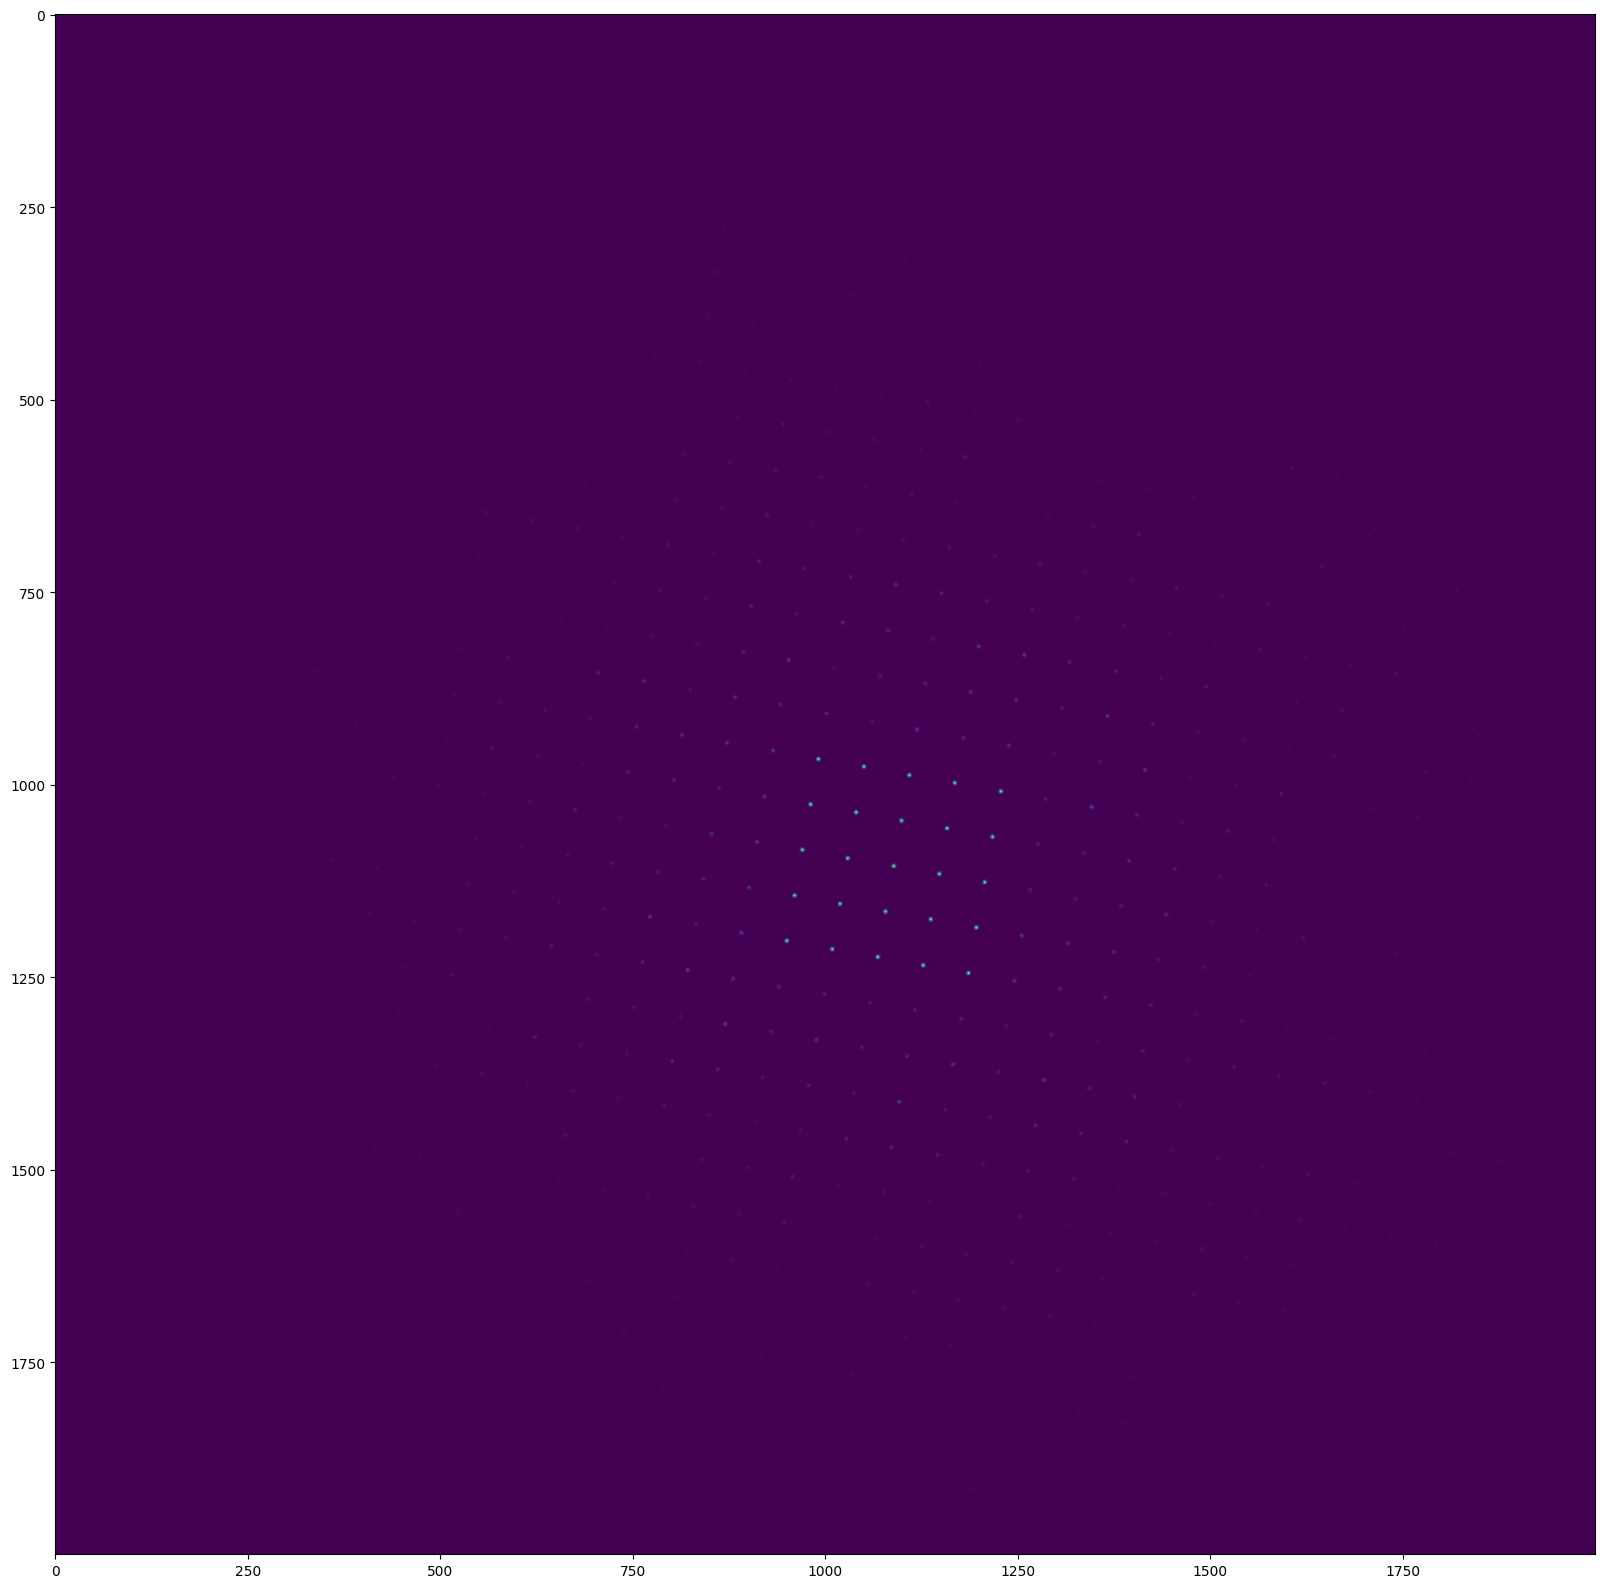

In [6]:

SLM_screen=SLM.phase_to_screen(SLM_Phase.cpu().clone().numpy())
fftAmp,fftPhase = SLM.phase_to_fftField(SLM_Phase.cpu())
plt.figure(figsize=(20,20))
plt.imshow(fftAmp[1000:3000,1000:3000])
plt.show()
# blinkslm.slm_lib.Delete_SDK()

In [7]:
blinkslm.write_image((SLM_screen).astype('uint8'))



NameError: name 'blinkslm' is not defined

In [ ]:
blinkslm.slm_lib.Delete_SDK()

1

In [ ]:
blinkslm.write_image((SLM_screen).astype('uint8'))

进行均匀性优化，读取IDS

In [ ]:

from ids_peak_camera import IDS_Peak_Camera
from ids_peak import ids_peak as peak
from ids_peak_ipl import ids_peak_ipl
import matplotlib.pyplot as plt
import numpy as np
from camera import AbstractCamera, ShutterMode
# selected_device=4108771588
IDS_Camera= IDS_Peak_Camera(init_camera=True,selected_device=0)

# print(IDS_Camera.m_device.RemoteDevice().NodeMaps()[IDS_Camera.selected_device])


('T', 'h', 'e', ' ', 'd', 'e', 'v', 'i', 'c', 'e', ' ', 'y', 'o', 'u', ' ', 's', 'e', 'l', 'e', 'c', 't', 'e', 'd', ' ', 'i', 's', ' ', 'n', 'o', 't', ' ', 'o', 'p', 'e', 'n', 'a', 'b', 'l', 'e', '!')


In [ ]:
IDS_Camera.SetROI()
IDS_Camera.SetBitDepth(12)

AttributeError: 'NoneType' object has no attribute 'FindNode'

In [ ]:
exposure_time = 20000
IDS_Camera.SetExposureTime(exposure_time)

In [ ]:
# IDS_Camera.PrepareAcquisition()
# IDS_Camera.AllocAndAnnounceBuffers()
# IDS_Camera.StartAcquisition()
IDS_Camera.SetTrigger(source='Software')
IDS_Camera.SetContinuousAcquisition
IDS_Camera._prepare_for_imaging(release_buffer=False)




##%%
image = IDS_Camera.GetImage()


(True, array([[ 73,  58,  65, ...,  64,  60,  61],
       [ 63,  73,  73, ...,  58,  64,  60],
       [ 68,  61,  54, ...,  56,  64,  64],
       ...,
       [ 89, 101,  89, ...,  79,  86,  70],
       [ 84,  90,  86, ...,  76,  77,  87],
       [ 98,  73,  91, ...,  85,  80,  84]], dtype=uint16))


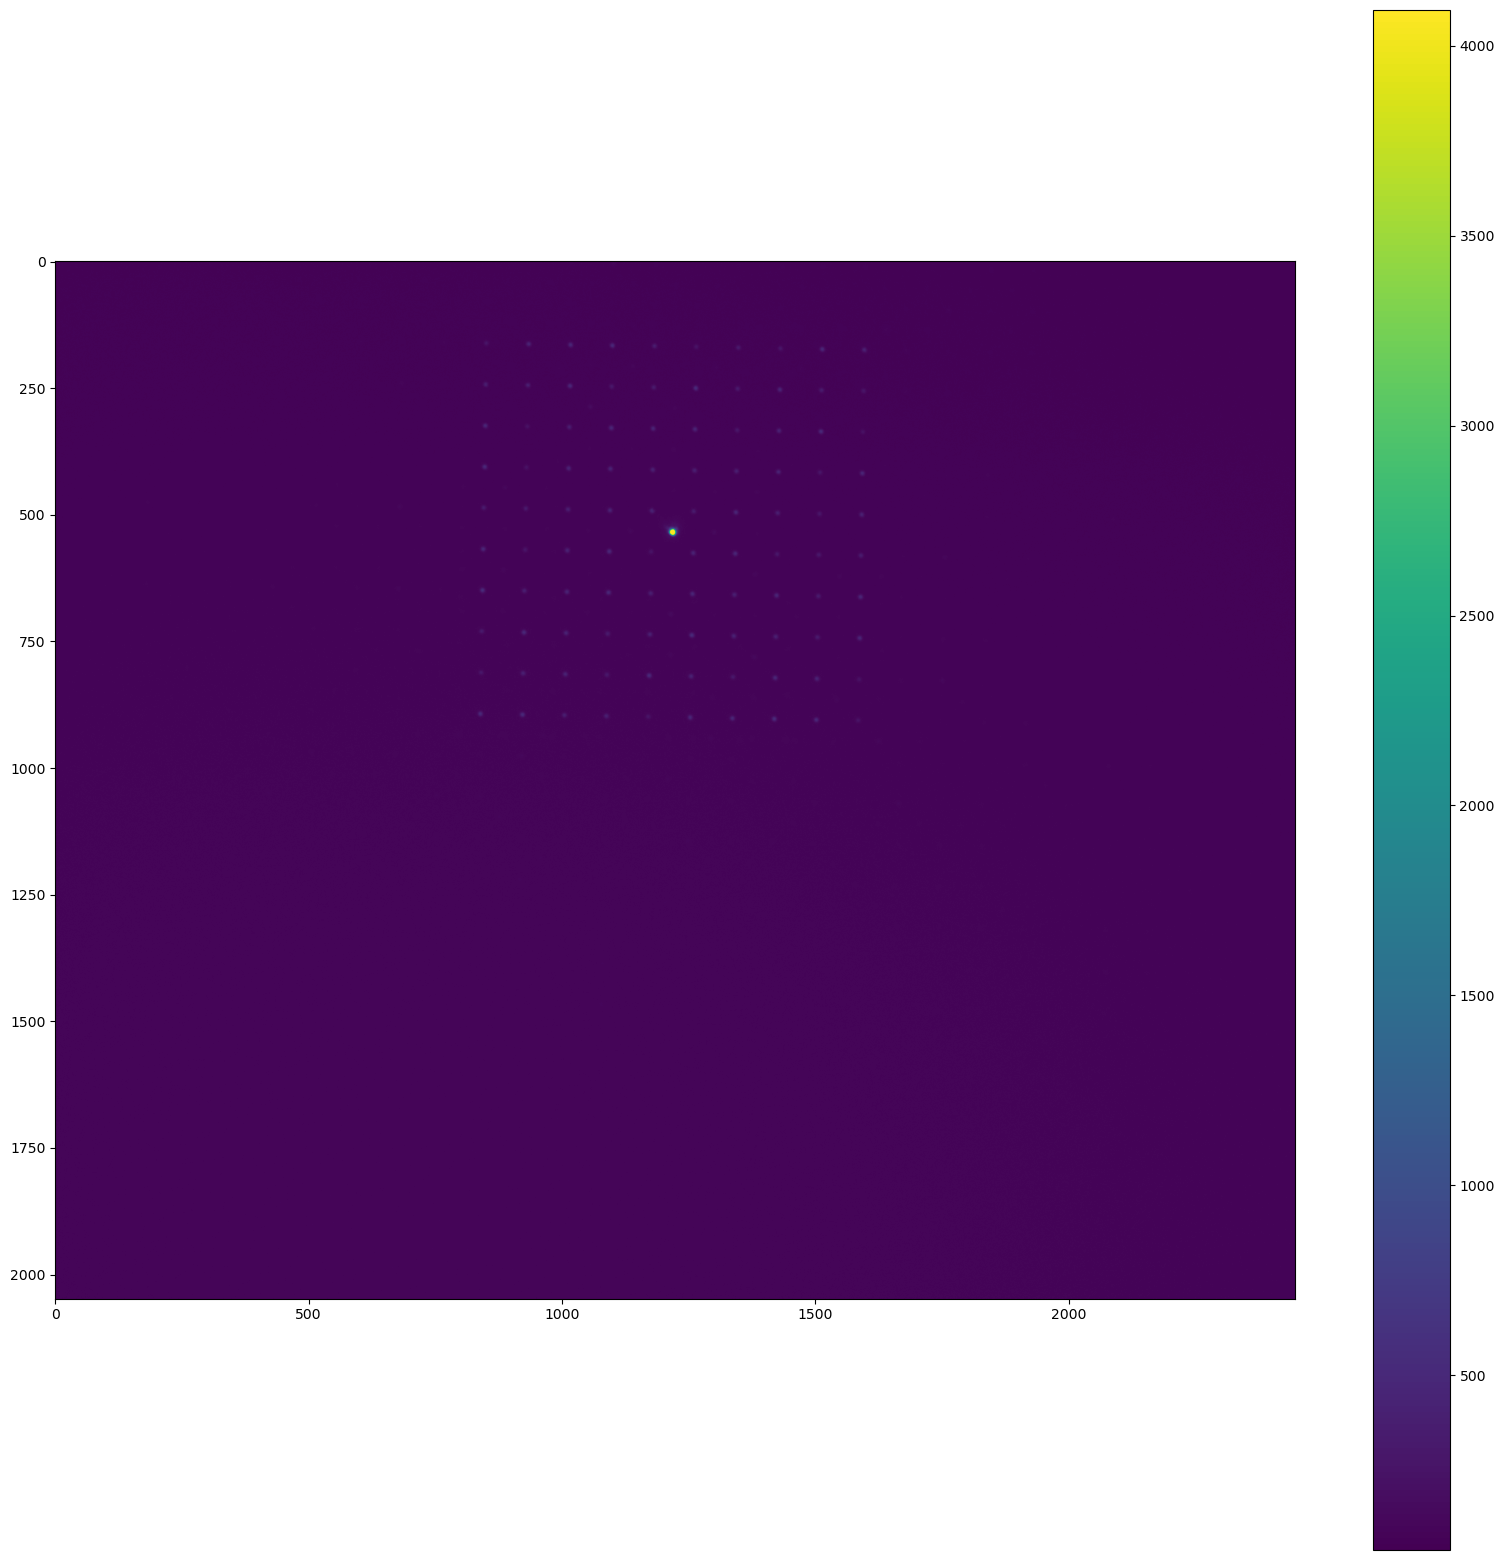

In [ ]:
print(image)
image=image[1]
# plt.imshow(image)
plt.figure(figsize=(20,20))
plt.imshow(image)
plt.colorbar()

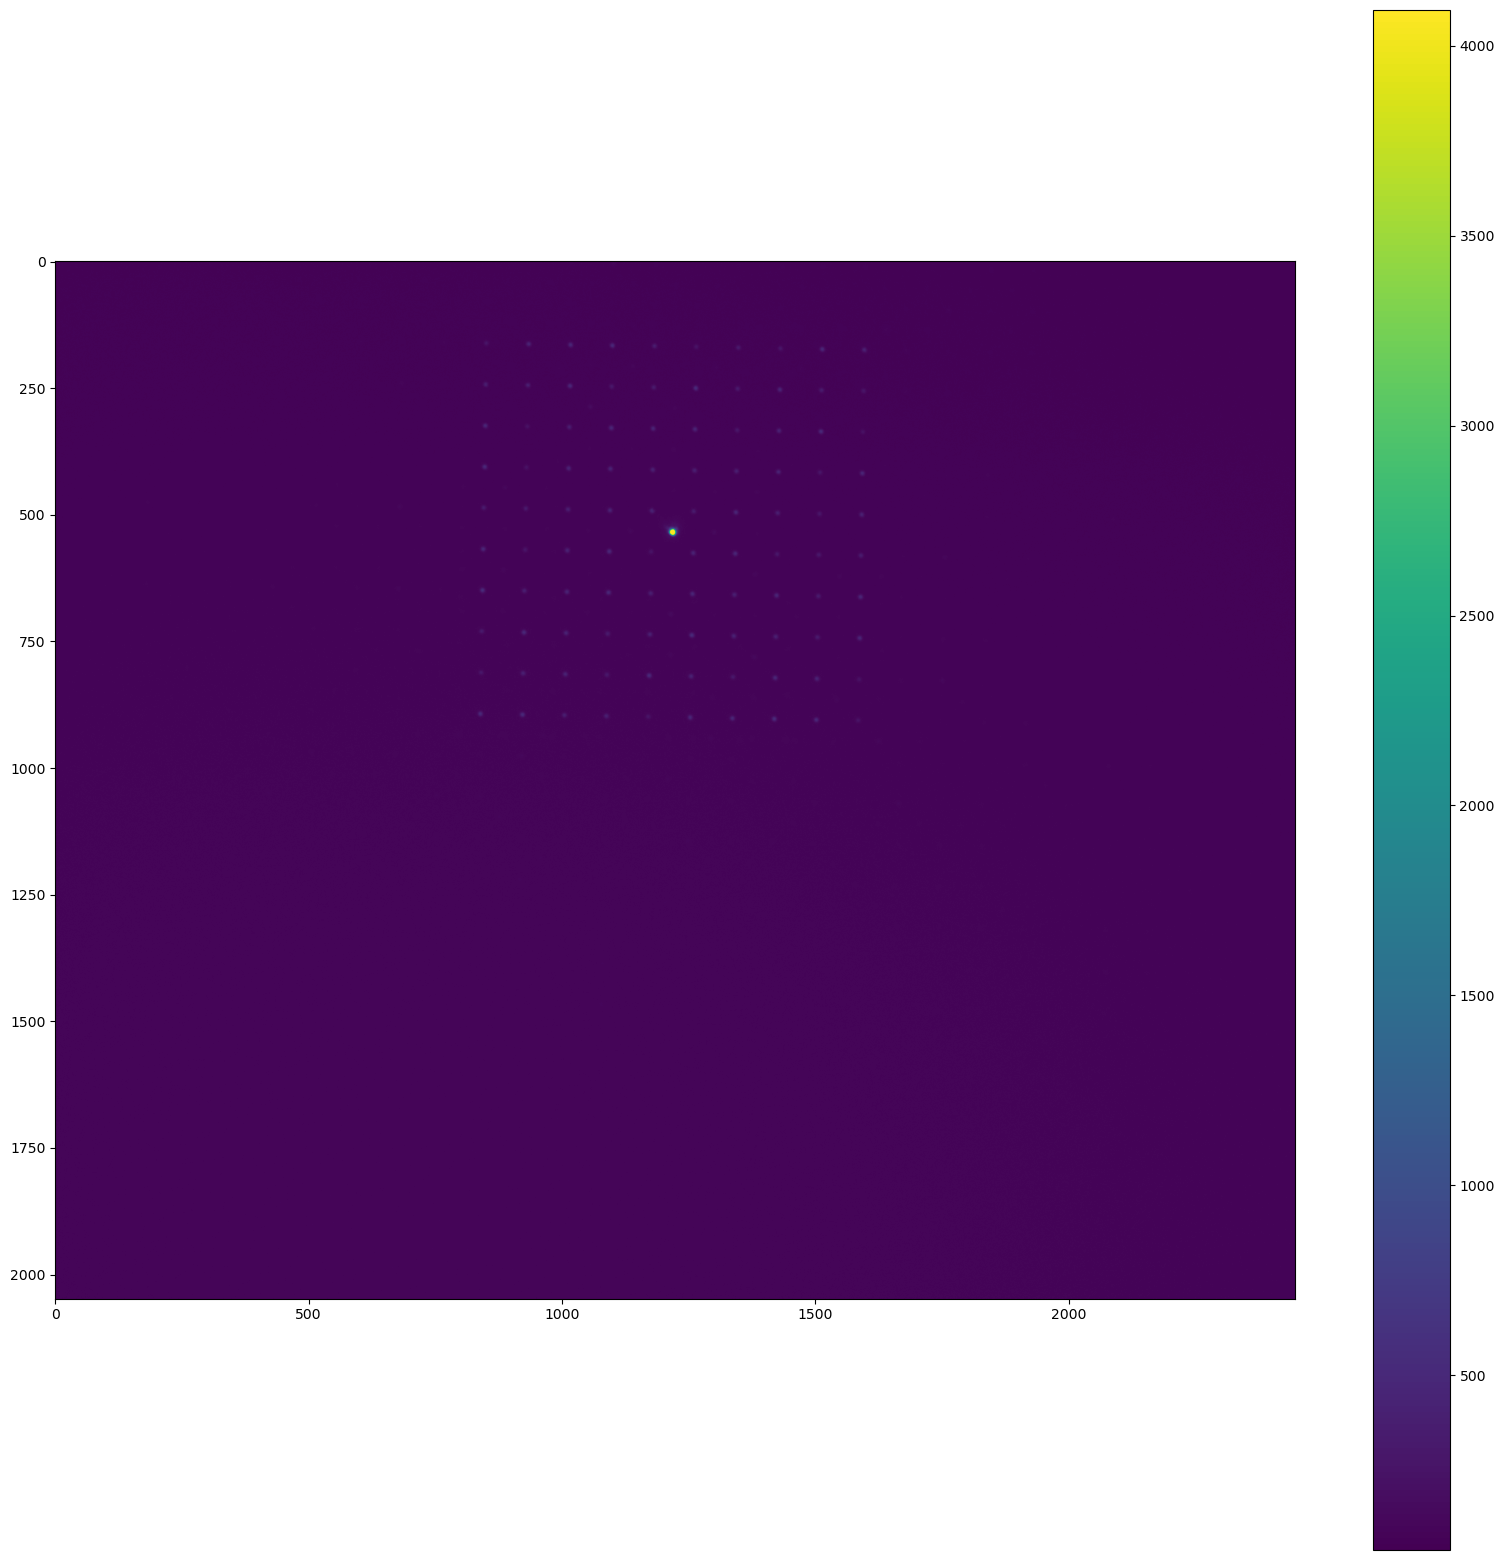

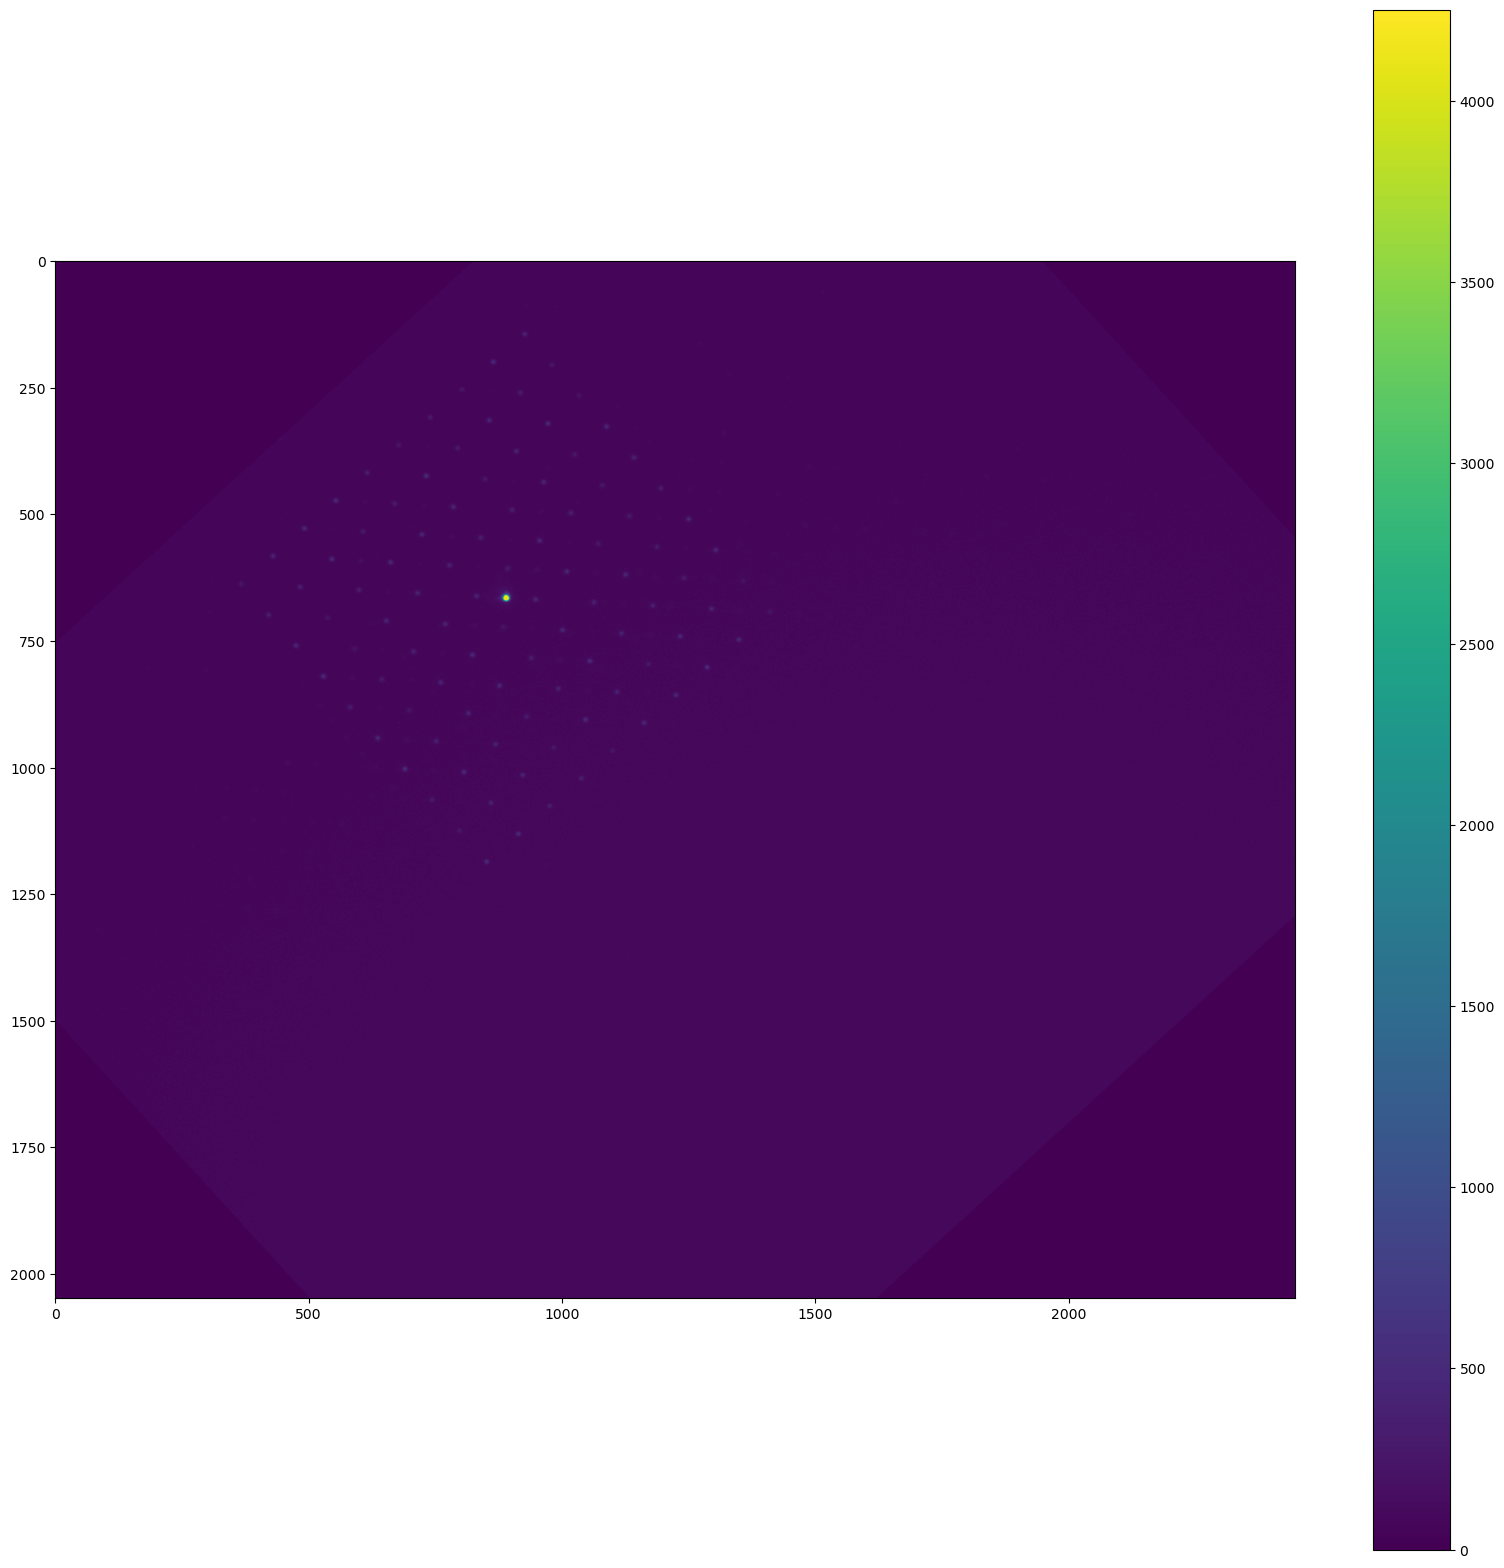

In [ ]:
from scipy.ndimage import binary_dilation, rotate
cutted_image = image
# rotated_image = rotate(cutted_image,angle=-4.8,reshape=False)
rotated_image = rotate(cutted_image,angle=42.4,reshape=False)

plt.figure(figsize=(20,20))
plt.imshow(cutted_image)
plt.colorbar()
plt.show()

plt.figure(figsize=(20,20))
plt.imshow(rotated_image)
plt.colorbar()
plt.show()

exposure time: 200
max: 46
sum: 1340628


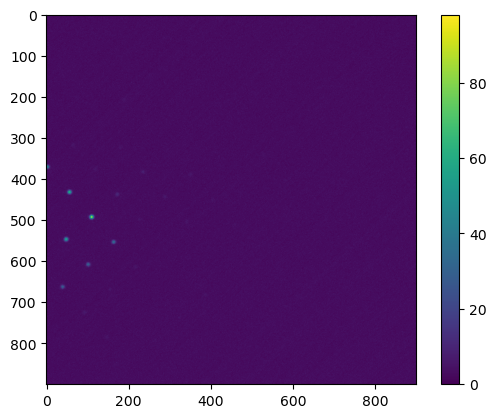

In [ ]:
##%%
plt.imshow(rotated_image[50:950,1050:1950])
plt.colorbar()
print('exposure time:',exposure_time)
print('max:',rotated_image[200:850,1200:1850].max())
print('sum:',rotated_image[200:850,1200:1850].sum())


In [ ]:
def non_uniformity_show(non_uniformity):
    non_uniformity = np.array(non_uniformity)
    min_index = np.argmin(non_uniformity)
    min_value = np.min(non_uniformity)
    plt.plot(non_uniformity)
    plt.plot(min_index,min_value,'.')
    plt.annotate(f'Minimum: {min_value:.3f}', xy=(min_index, min_value),
                xytext=(min_index + 1, min_value),
                arrowprops=dict(facecolor='black', arrowstyle='->'))
    plt.title('Tweezer Uniformity Optimization')
    plt.xlabel('Number of iterations')
    plt.ylabel('Non uniformity')
    plt.show()

# 适用于4f系统优化
def camera_intensity_array_generate(intensity):
    intensity = np.array(intensity)
    intensity_2d_array = intensity.reshape(25,43)
    intensity_flip = np.transpose(intensity_2d_array)
    intensity_flip = np.flip(intensity_flip, axis=1)
    camera_intensity_array = intensity_flip.flatten()

    return camera_intensity_array

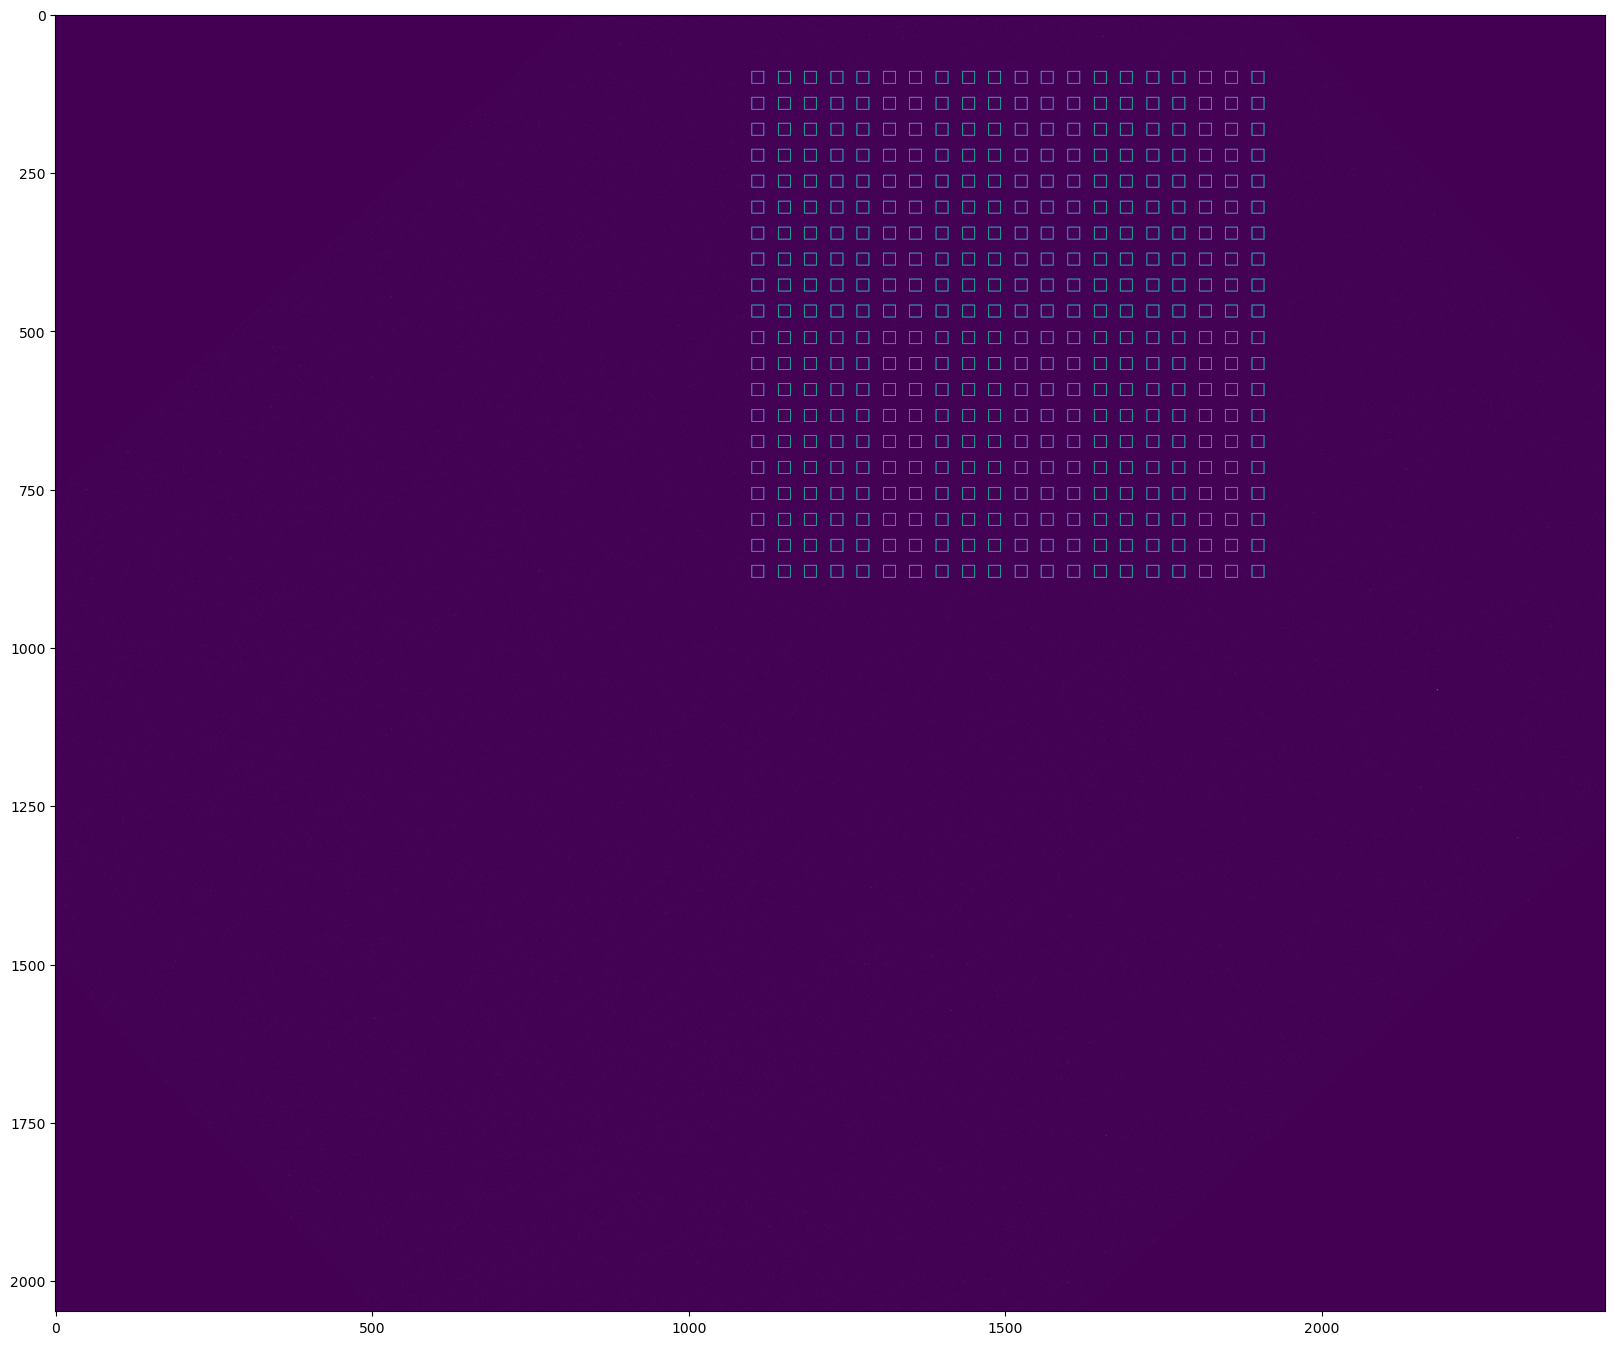

In [ ]:
from TweezerArrayRegionsExtraction import *
# 50:950,1050:1950
points = generate_points([100,1110],[100,1900], [880,1110],[880,1900],[20,20])
# points = generate_points_Tri([266,423],[259,2058], [1876,428],[1872,2063],[43,37])
# points = generate_points_kagome([261,400],[258,2011], [1879,400],[1879,2012],[40,34])
regions = generate_regions(points, [20,20])
# 找到点
aoi = generate_aoi(regions, rotated_image, 2000)

plt.figure(figsize=(20,20))
plt.imshow(rotated_image+aoi)

[[ 870  890 1100 1120]
 [ 870  890 1142 1162]
 [ 870  890 1183 1203]
 ...
 [  90  110 1807 1827]
 [  90  110 1848 1868]
 [  90  110 1890 1910]]


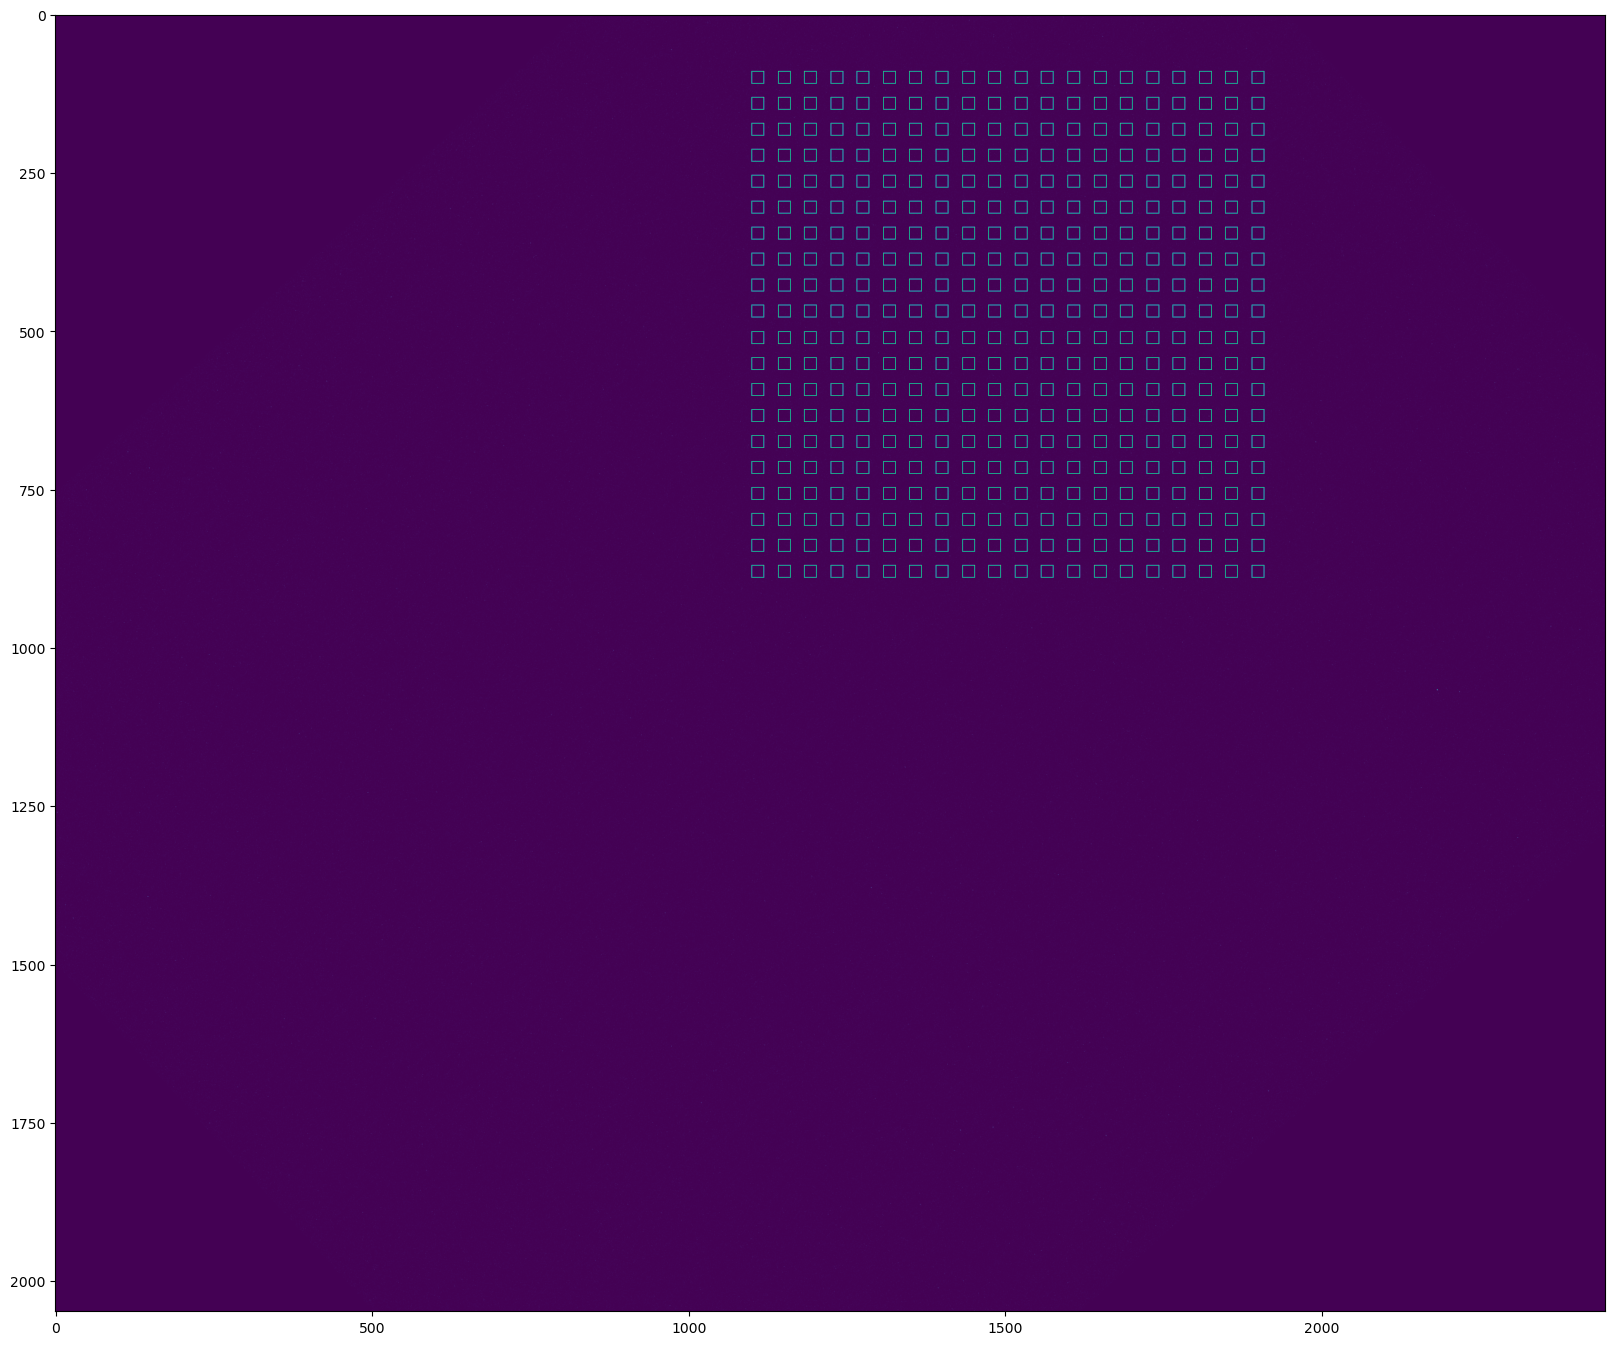

In [ ]:
regions_trans = np.flip(np.transpose(regions.reshape(20,20,4),axes=(1,0,2)),axis=0).reshape(-1,4)
# regions_trans = regions_trans[c]#point select order
aoi = generate_aoi(regions_trans, rotated_image, 2000)
# print(regions_trans)
plt.figure(figsize=(20,20))
plt.imshow(rotated_image+aoi)
print(regions_trans)

In [ ]:
regions = regions_trans
##%%
x1 = regions[:,0]
x2 = regions[:,1]
y1 = regions[:,2]
y2 = regions[:,3]

In [ ]:
array_size = [20,20]
index = 0
non_uniformity = []
intensity_data = []
targetAmp_data = []
optimize = True
time_interval = 1
rep = 5



0.06136343895938064


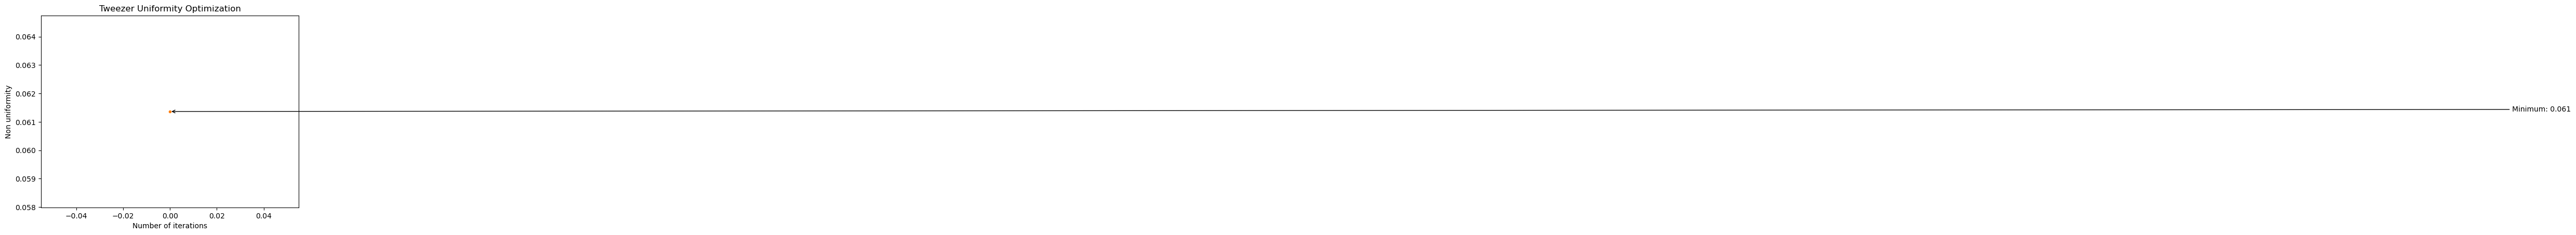

In [ ]:
intensity = []
image_ROI = []
for i  in range(array_size[0]*array_size[1]):
        image_ROI.append(rotated_image[x1[i]:x2[i],y1[i]:y2[i]])

for i  in range(array_size[0]*array_size[1]):
        # popt, pcov, fitted_image = gaussian_2d_fit(image_ROI[i], show=False)
        # intensity.append(popt[0])
        intensity.append(image_ROI[i].sum())



intensity = np.array(intensity)
camera_intensity = np.flip(intensity)
intensity_data.append(camera_intensity)
non_uniformity.append(camera_intensity.std()/camera_intensity.mean())
print(camera_intensity.std()/camera_intensity.mean())
non_uniformity_show(non_uniformity)


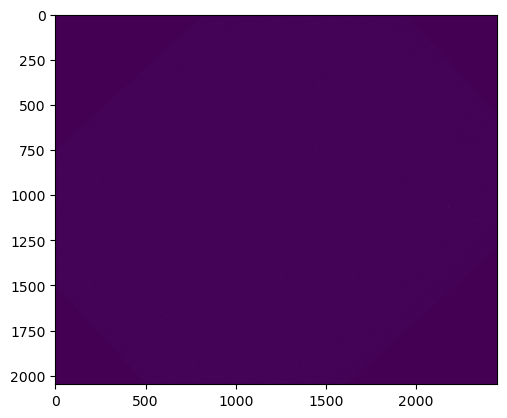

In [ ]:
blinkslm.write_image((SLM_screen).astype('uint8'))
image = IDS_Camera.GetImage()
image=image[1]
cutted_image = image
rotated_image = rotate(cutted_image,angle=42.4,reshape=False)
plt.imshow(rotated_image)

In [ ]:
while True:

    if optimize:
        blinkslm.write_image((SLM_screen).astype('uint8'))

    time.sleep(time_interval)

    image = IDS_Camera.GetImage()
    image=image[1]
    cutted_image = image
    rotated_image = rotate(cutted_image,angle=42.4,reshape=False)

    image_ROI = []
    intensity = []

    for i  in range(array_size[0]*array_size[1]):
        image_ROI.append(rotated_image[x1[i]:x2[i],y1[i]:y2[i]])

    for i  in range(array_size[0]*array_size[1]):
        # popt, pcov, fitted_image = gaussian_2d_fit(image_ROI[i], show=False)
        # intensity.append(popt[0])
        intensity.append(image_ROI[i].sum())


    intensity = np.array(intensity)
    # non_uniformity.append(intensity.std()/intensity.mean())
    # camera_intensity = camera_intensity_array_generate(intensity)
    camera_intensity = np.flip(intensity)
    intensity_data.append(camera_intensity)
    non_uniformity.append(camera_intensity.std()/camera_intensity.mean())
    print(camera_intensity.std()/camera_intensity.mean())
   
    if camera_intensity.std()/camera_intensity.mean()< 0.001 or index == rep:
        break

    index += 1
    if index % 1 ==0:
        print('\n')
        print(index)


    if optimize:
        
        # camera_intensity_array = camera_intensity_array_generate(intensity)
        print(intensity)
        camera_intensity_array = np.flip(intensity)
        cameraAmp = SLM.camera_Amp_generate(targetAmp, camera_intensity_array)
        targetAmp = SLM.target_adapt(targetAmp, cameraAmp)
        targetAmp_data.append(targetAmp)

        print('Start the new SLM phase generation ...')

        SLM_Phase = WGS.WGS_phase_generate(torch.from_numpy(SLM.initGaussianAmp), SLM_Phase, torch.from_numpy(targetAmp), Loop=20, threshold=0.01)
        SLM_screen=SLM.phase_to_screen(SLM_Phase.cpu().clone().numpy())
        slm_screen_f_corrected = SLM_screen 

        # SLM.target_and_phase_save(targetAmp, SLM_Phase.cpu().clone().numpy(), slm_screen_f_corrected, info = "stagger",
        #                         adapt_times='-sum-'+str(index))


non_uniformity_show(non_uniformity)

plt.figure(figsize=(20,20))
plt.imshow(rotated_image)
plt.colorbar()
plt.show()


0.06196611920848703


1
[4530 4792 4827 5122 5188 4786 5344 5414 5050 4894 4688 5188 5028 4782
 4857 4416 5502 5360 4575 4917 5221 5329 4655 4833 5729 4765 4316 5650
 5092 5189 4612 4724 5069 4881 4799 4683 4410 4991 5155 4515 5173 5446
 4482 5317 4557 5535 4916 4427 5044 5505 5127 4580 4800 4646 4943 5048
 5114 4816 5119 5109 4815 4853 5427 4877 4505 5266 4954 4981 4855 5051
 4857 4964 4860 4970 4591 4973 5391 4581 4738 4686 4945 4660 4711 5090
 4734 5127 4865 5128 4751 4861 4997 4638 4500 4989 4788 4593 4706 4892
 4731 4654 4955 5429 5272 5315 4902 4977 4730 5040 5113 5354 4750 4968
 5704 5223 4483 4360 4642 4815 5267 4940 5443 5274 4708 4757 5197 5307
 5115 5280 4940 5014 5473 5105 5162 5238 5014 4746 5057 4675 4709 4615
 4891 5194 5070 5100 4409 5238 4846 4973 4837 5813 4942 5076 5303 4801
 4494 4794 4527 4451 4245 5191 4625 5490 4878 5277 5368 5116 5286 5012
 5387 5021 5106 4707 4957 4707 5278 4678 5132 5184 5207 4310 5143 4921
 4898 5618 5013 4956 4984 5035 5111 4830 4831 4806 46

ValueError: shape mismatch: value array of shape (400,) could not be broadcast to indexing result of shape (25,)

In [ ]:
blinkslm.slm_lib.Delete_SDK()
IDS_Camera.StopAcquisition()
IDS_Camera.Close()

NameError: name 'IDS_Camera' is not defined